# Telco Customer Churn — Predictive Retention Analysis
## Notebook 01 · Extract & Quality Check

| | |
|---|---|
| **Author** | Natalia Stekolnikova |
| **Course** | IFCT153PO — Big Data & Business Intelligence |
| **Date** | April 2026 |
| **Dataset** | IBM Telco Customer Churn (Kaggle) |

---

### Business problem

Customer churn — the loss of subscribers to a competitor — is one of the highest-cost problems in the telecommunications industry. Acquiring a new customer costs **5–25× more** than retaining an existing one (Harvard Business Review). A 5% reduction in churn rate can increase profitability by 25–95%.

This project builds an end-to-end Data Science pipeline to:
1. **Identify** customers at high risk of churning before they leave
2. **Quantify** the financial impact of churn on the business
3. **Recommend** data-driven retention actions prioritised by expected ROI

### Dataset
IBM synthetic dataset representing a US telecom provider. Each row is one customer observed at a single point in time. The `Churn` column indicates whether the customer left within the last month.

### Pipeline
```
01_Extract_QualityCheck    
02_Clean_Transform
03_Load_SQLite
04_EDA_Insights_ML_XAI_BusinessImpact

```

### Folder structure
```
project/
├── data/
│   └── WA_Fn-UseC_-Telco-Customer-Churn.csv
├── notebooks/
│   └── 01_Extract_QualityCheck.ipynb
└── outputs/
```

---
## 0 · Environment

In [54]:
import os, warnings
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.figsize'   : (12, 4),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'font.size'        : 10,
})
PALETTE = {'No': '#2ecc71', 'Yes': '#e74c3c'}

print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
print(f'seaborn {sns.__version__}')

pandas  2.2.2
numpy   1.26.4
seaborn 0.13.2


---
## 1 · Extract

### 1.1 · Path resolution

Paths are resolved relative to this notebook using `pathlib.Path`. 

In [56]:
from pathlib import Path

# In Jupyter, __file__ is not defined — we use a workaround
try:
    # Works when running as a script
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    # Works in Jupyter — gets the current working directory
    NOTEBOOK_DIR = Path().resolve()

if (NOTEBOOK_DIR.parent / 'data').exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent  
else:
    PROJECT_ROOT = NOTEBOOK_DIR         

DATA_DIR   = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

assert DATA_FILE.exists(), (
    f'\nDataset not found.\n'
    f'Expected location: {DATA_FILE}\n'
    f'\nMake sure your project folder looks like this:\n'
    f'  churn_project/\n'
    f'  ├── data/\n'
    f'  │   └── WA_Fn-UseC_-Telco-Customer-Churn.csv\n'
    f'  ├── notebooks/\n'
    f'  │   └── this_notebook.ipynb\n'
    f'  └── outputs/\n'
)

print(f'Project root : {PROJECT_ROOT}')
print(f'Data         : {DATA_DIR}')
print(f'Outputs      : {OUTPUT_DIR}')
print(f'Dataset      : {DATA_FILE.name}  ({DATA_FILE.stat().st_size/1024:.1f} KB)')
print(f'\nReady to run on any machine.')

Project root : C:\Users\natal\Documents\churn_project
Data         : C:\Users\natal\Documents\churn_project\data
Outputs      : C:\Users\natal\Documents\churn_project\outputs
Dataset      : WA_Fn-UseC_-Telco-Customer-Churn.csv  (954.6 KB)

Ready to run on any machine.


### 1.2 · Load

`df_raw` is kept **immutable** throughout the entire project. All transformations happen on `df = df_raw.copy()`. This is standard practice: if something goes wrong downstream, you can always `df = df_raw.copy()` and restart from a known-good state without re-reading the file.

In [58]:
df_raw = pd.read_csv(DATA_FILE)
df     = df_raw.copy()

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


### 1.3 · Column inventory

Before touching any data, we build a structured **column inventory**. This serves as living documentation: it records what each column is, what group it belongs to, and its current state. On projects with hundreds of features this step saves hours of confusion later.

In [60]:
# ── Column inventory ─────────────────────────────────────────
groups = {
    'id'         : ['customerID'],
    'demographic': ['gender', 'SeniorCitizen', 'Partner', 'Dependents'],
    'account'    : ['tenure', 'Contract', 'PaperlessBilling',
                    'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
    'services'   : ['PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies'],
    'target'     : ['Churn'],
}
col_to_group = {col: grp for grp, cols in groups.items() for col in cols}

# Use df_raw column list to count only the original 21 columns
# df may contain helper columns added in later cells (TotalCharges_num, Churn_bin)
original_cols = df_raw.columns.tolist()

inventory = pd.DataFrame({
    'group'   : pd.Series(col_to_group),
    'dtype'   : df[original_cols].dtypes.astype(str),
    'null'    : df[original_cols].isna().sum(),
    'n_unique': df[original_cols].nunique(),
})

display(inventory)

n_num = df[original_cols].select_dtypes('number').shape[1]
n_obj = df[original_cols].select_dtypes('object').shape[1]
print(f'\nNumeric columns : {n_num}  ({list(df[original_cols].select_dtypes("number").columns)})')
print(f'String columns  : {n_obj}')
print(f'Total           : {len(original_cols)}')
print()
print('Note: TotalCharges is string (object) despite being a monetary value.')
print('MonthlyCharges was correctly parsed as float64 — TotalCharges was not,')
print('because 11 cells contain blank strings which prevented automatic type detection.')
print('This will be addressed in Quality Check section 2.2.')

,group,dtype,null,n_unique
Churn,target,object,0,2
Contract,account,object,0,3
Dependents,demographic,object,0,2
DeviceProtection,services,object,0,3
InternetService,services,object,0,3
MonthlyCharges,account,float64,0,1585
MultipleLines,services,object,0,3
OnlineBackup,services,object,0,3
OnlineSecurity,services,object,0,3
PaperlessBilling,account,object,0,2



Numeric columns : 3  (['SeniorCitizen', 'tenure', 'MonthlyCharges'])
String columns  : 18
Total           : 21

Note: TotalCharges is string (object) despite being a monetary value.
MonthlyCharges was correctly parsed as float64 — TotalCharges was not,
because 11 cells contain blank strings which prevented automatic type detection.
This will be addressed in Quality Check section 2.2.


### 1.4 · Descriptive statistics

**Numeric variables** — we transpose `.describe()` so each feature occupies a row, making it easier to scan across statistics.

**Categorical variables** — `customerID` is excluded because frequency counts on a unique identifier produce 7,043 rows of noise with zero analytical value.

In [62]:
print('── Numeric ──')
display(df.describe().T.round(2))

cat_cols = [c for c in df.select_dtypes('object').columns if c != 'customerID']
print('\n── Categorical value counts ──')
for col in cat_cols:
    vc  = df[col].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(1)
    display(pd.DataFrame({'count': vc, '%': pct}).rename_axis(col))

── Numeric ──


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0000,0.1600,0.3700,0.0000,0.0000,0.0000,0.0000,1.0000
tenure,7043.0000,32.3700,24.5600,0.0000,9.0000,29.0000,55.0000,72.0000
MonthlyCharges,7043.0000,64.7600,30.0900,18.2500,35.5000,70.3500,89.8500,118.7500



── Categorical value counts ──


,count,%
gender,,
Male,3555,50.5000
Female,3488,49.5000


,count,%
Partner,,
No,3641,51.7000
Yes,3402,48.3000


...

,count,%
Contract,,
Month-to-month,3875,55.0000
Two year,1695,24.1000
One year,1473,20.9000


,count,%
PaperlessBilling,,
Yes,4171,59.2000
No,2872,40.8000


,count,%
PaymentMethod,,
Electronic check,2365,33.6000
Mailed check,1612,22.9000
Bank transfer (automatic),1544,21.9000
Credit card (automatic),1522,21.6000


,count,%
TotalCharges,,
,11,0.2000
20.2,11,0.2000
19.75,9,0.1000
20.05,8,0.1000
19.9,8,0.1000
...,...,...
6849.4,1,0.0000
692.35,1,0.0000
130.15,1,0.0000


,count,%
Churn,,
No,5174,73.5000
Yes,1869,26.5000


### 1.5 · Target variable — Churn distribution

With a 73.5% / 26.5% split, the dataset is **moderately imbalanced** (2.77:1 ratio). This is not severe enough to require aggressive resampling, but it does mean:
- **Accuracy is a misleading metric** — a model that always predicts "No churn" achieves 73.5% accuracy while being completely useless
- We must use **AUC-ROC, Precision-Recall and F1** as primary evaluation metrics
- At the modelling stage (Notebook 05) I will use `class_weight='balanced'` or SMOTE to compensate

Churn distribution


,count,%
Churn,,
No,5174,73.5000
Yes,1869,26.5000



Class imbalance ratio : 2.77:1  (No:Yes)
 Accuracy is not a reliable metric for this dataset.
 Primary metrics at modelling stage: AUC-ROC, F1, Precision-Recall curve.


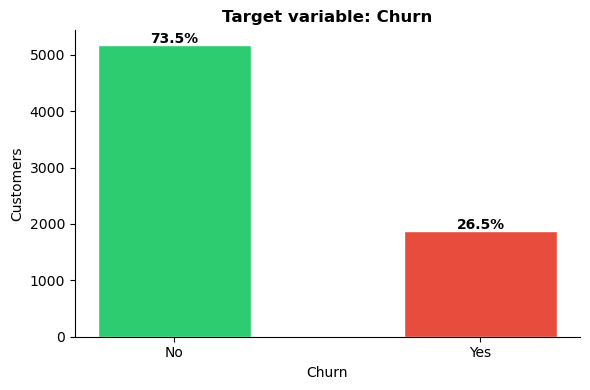

In [64]:
churn_vc  = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(1)

print('Churn distribution')
display(pd.DataFrame({'count': churn_vc, '%': churn_pct}))
print(f'\nClass imbalance ratio : {churn_vc["No"]/churn_vc["Yes"]:.2f}:1  (No:Yes)')
print(' Accuracy is not a reliable metric for this dataset.')
print(' Primary metrics at modelling stage: AUC-ROC, F1, Precision-Recall curve.')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    churn_vc.index, churn_vc.values,
    color=[PALETTE[k] for k in churn_vc.index],
    width=0.5, edgecolor='white'
)
for bar, (label, pct) in zip(bars, churn_pct.items()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 40,
            f'{pct}%', ha='center', fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Customers')
ax.set_title('Target variable: Churn')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p01_churn_distribution.png', dpi=150)
plt.show()

### 1.6 · Encoding direction verification

Before encoding `Churn` as 0/1 we **verify the direction** against known business logic. This is a critical sanity check that is often skipped and causes silent model failures.

Expected relationships if `Yes=1` is correct:
- Churned customers (`Churn=1`) should have **lower `tenure`** — they left sooner
- Churned customers should have **higher `MonthlyCharges`** — expensive plans drive churn
- Churned customers should have **lower `TotalCharges`** — less time paying = less total spend

If any assertion fails, the encoding is reversed and all downstream models would learn the opposite of reality.

In [66]:
# Create numeric TotalCharges for this check
if 'TotalCharges_num' not in df.columns:
    df['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['Churn_bin'] = df['Churn'].map({'Yes': 1, 'No': 0})

check = df.groupby('Churn_bin')[['tenure','MonthlyCharges','TotalCharges_num']].mean().round(2)
display(check)

# Business logic assertions
assert check.loc[1,'tenure']            < check.loc[0,'tenure'], \
    'FAIL: churned customers should have lower tenure'
assert check.loc[1,'TotalCharges_num']  < check.loc[0,'TotalCharges_num'], \
    'FAIL: churned customers should have lower TotalCharges'
assert check.loc[1,'MonthlyCharges']    > check.loc[0,'MonthlyCharges'], \
    'FAIL: churned customers should have higher MonthlyCharges'

print('Encoding confirmed: Yes=1, No=0 is correct')
print()
print('Interpretation:')
print(f'  Churned customers stayed {check.loc[1,"tenure"]:.1f} months on average'
      f' vs {check.loc[0,"tenure"]:.1f} months for retained — {check.loc[0,"tenure"]/check.loc[1,"tenure"]:.1f}x longer.')
print(f'  Churned customers paid €{check.loc[1,"MonthlyCharges"]:.2f}/month'
      f' vs €{check.loc[0,"MonthlyCharges"]:.2f} — expensive plans correlate with higher churn.')
print(f'  Total revenue lost per churned customer: €{check.loc[1,"TotalCharges_num"]:.0f}'
      f' vs €{check.loc[0,"TotalCharges_num"]:.0f} lifetime value for retained customers.')

,tenure,MonthlyCharges,TotalCharges_num
Churn_bin,,,
0,37.5700,61.2700,2555.3400
1,17.9800,74.4400,1531.8000


Encoding confirmed: Yes=1, No=0 is correct

Interpretation:
  Churned customers stayed 18.0 months on average vs 37.6 months for retained — 2.1x longer.
  Churned customers paid €74.44/month vs €61.27 — expensive plans correlate with higher churn.
  Total revenue lost per churned customer: €1532 vs €2555 lifetime value for retained customers.


---
## 2 · Quality Check

A quality check follows a fixed sequence: **detect first, interpret second, fix in the next notebook**. Every finding below is computed from actual data — no conclusions are stated before the code runs.

| Check | What we look for |
|---|---|
| 2.1 | Explicit NaN values |
| 2.2 | Implicit NaN — blank strings masquerading as valid values |
| 2.3 | Dtype mismatches — columns stored as wrong type |
| 2.4 | Categorical inconsistencies — redundant or non-standard labels |
| 2.5 | Logical contradictions — values that are individually valid but impossible together |
| 2.6 | Duplicate rows |
| 2.7 | Outliers — IQR method |
| 2.8 | Preliminary signal — do the raw features already show churn patterns? |

### 2.1 · Explicit missing values

,null_count,null_%
TotalCharges_num,11,0.1600


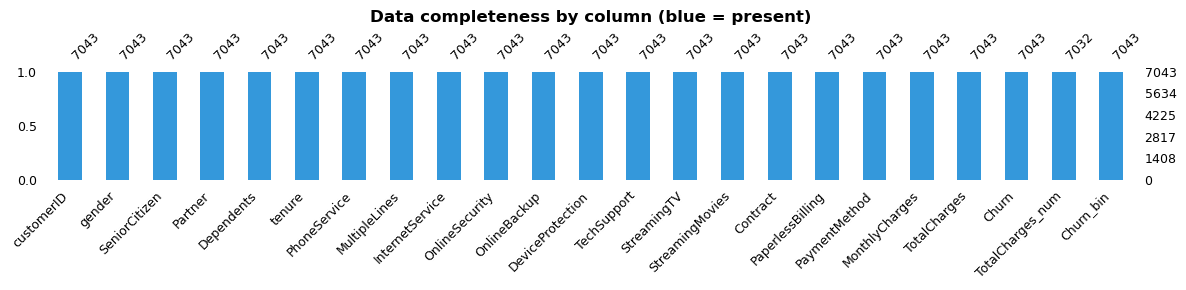

In [69]:
null_counts = df.isna().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_report = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
null_report = null_report[null_report['null_count'] > 0]

if null_report.empty:
    print('No explicit NaN values in any column.')
    print('Important: this does not mean the data is complete.')
    print('Blank strings and whitespace-only values are invisible to isna() — see 2.2.')
else:
    display(null_report)

fig, ax = plt.subplots(figsize=(12, 3))
msno.bar(df, ax=ax, color='#3498db', fontsize=9)
ax.set_title('Data completeness by column (blue = present)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p02_missing_values.png', dpi=150)
plt.show()

### 2.2 · Implicit missing values — TotalCharges

`TotalCharges` is stored as `object` (string) despite being a monetary amount. When pandas reads a CSV, any cell that cannot be parsed as a number is silently kept as a string — including blank cells. `isna()` returns `False` for these because the cell contains a string (an empty one), not a Python `None`.

The diagnostic: force numeric conversion with `errors='coerce'`. Any value that fails to convert becomes `NaN`, making the hidden blanks visible.

In [71]:
print(f'TotalCharges dtype          : {df["TotalCharges"].dtype}  (expected float64)')
print(f'Explicit NaN before coerce  : {df["TotalCharges"].isna().sum()}')

tc_numeric     = pd.to_numeric(df['TotalCharges'], errors='coerce')
implicit_nulls = tc_numeric.isna().sum()
print(f'NaN after coerce            : {implicit_nulls}   blank strings unmasked')
print()

mask_blank = tc_numeric.isna()
affected   = df.loc[mask_blank, ['customerID','tenure','MonthlyCharges','TotalCharges','Contract','Churn']]
display(affected)

print()
print('Findings:')
print(f'  All {implicit_nulls} affected rows have tenure = 0.')
print(f'  All {implicit_nulls} are on long-term contracts (One year / Two year).')
print(f'  None have churned — they are active new customers.')
print()
print('Business interpretation:')
print('  These customers signed a long-term contract but the data was captured')
print('  before their first billing cycle completed. TotalCharges is blank')
print('  because the system had not yet posted the first invoice.')
print()
print('Proposed fix (Notebook 02):')
print('  TotalCharges <- MonthlyCharges (impute as one month of service).')
print('  Rationale: conservative lower-bound estimate for first billing cycle.')

TotalCharges dtype          : object  (expected float64)
Explicit NaN before coerce  : 0
NaN after coerce            : 11   blank strings unmasked



,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.5500,,Two year,No
753,3115-CZMZD,0,20.2500,,Two year,No
936,5709-LVOEQ,0,80.8500,,Two year,No
1082,4367-NUYAO,0,25.7500,,Two year,No
1340,1371-DWPAZ,0,56.0500,,Two year,No
3331,7644-OMVMY,0,19.8500,,Two year,No
3826,3213-VVOLG,0,25.3500,,Two year,No
4380,2520-SGTTA,0,20.0000,,Two year,No
5218,2923-ARZLG,0,19.7000,,One year,No
6670,4075-WKNIU,0,73.3500,,Two year,No



Findings:
  All 11 affected rows have tenure = 0.
  All 11 are on long-term contracts (One year / Two year).
  None have churned — they are active new customers.

Business interpretation:
  These customers signed a long-term contract but the data was captured
  before their first billing cycle completed. TotalCharges is blank
  because the system had not yet posted the first invoice.

Proposed fix (Notebook 02):
  TotalCharges <- MonthlyCharges (impute as one month of service).
  Rationale: conservative lower-bound estimate for first billing cycle.


### 2.3 · Dtype audit

I define the **expected** dtype for every column and flag mismatches automatically. 

Note on `category`: this is a pandas memory-optimisation type, not a model-ready encoding. String columns with low cardinality consume far less RAM as `category`. The actual encoding for ML (Label Encoding, One-Hot) happens in Notebook 02.

In [73]:
expected = {
    'customerID'      : 'object',    # identifier — excluded from models
    'gender'          : 'category',
    'SeniorCitizen'   : 'category',  # stored as int64 (0/1); all other binary cols use Yes/No
    'Partner'         : 'category',
    'Dependents'      : 'category',
    'tenure'          : 'int64',
    'PhoneService'    : 'category',
    'MultipleLines'   : 'category',
    'InternetService' : 'category',
    'OnlineSecurity'  : 'category',
    'OnlineBackup'    : 'category',
    'DeviceProtection': 'category',
    'TechSupport'     : 'category',
    'StreamingTV'     : 'category',
    'StreamingMovies' : 'category',
    'Contract'        : 'category',  # ordinal: Month-to-month < One year < Two year
    'PaperlessBilling': 'category',
    'PaymentMethod'   : 'category',
    'MonthlyCharges'  : 'float64',
    'TotalCharges'    : 'float64',   # currently object — contains blank strings
    'Churn'           : 'int64',     # currently object Yes/No → encode as 1/0
}

type_audit = pd.DataFrame({
    'current_dtype' : df[list(expected.keys())].dtypes.astype(str),
    'expected_dtype': pd.Series(expected),
})
type_audit['mismatch'] = type_audit['current_dtype'] != type_audit['expected_dtype']

display(type_audit)

n_mismatch = type_audit['mismatch'].sum()
print(f'\nColumns with dtype mismatch: {n_mismatch}')
print()
mismatched = type_audit[type_audit['mismatch']]
display(mismatched[['current_dtype','expected_dtype']])
print()
print('Key observations:')
print('  TotalCharges  : object → float64 required for any arithmetic or scaling')
print('  SeniorCitizen : int64 (0/1) → inconsistent with all other binary columns (Yes/No)')
print('                  Risk: model could interpret 0/1 as ordinal magnitude, not category')
print('  Churn         : string Yes/No → must be encoded 1/0 before any ML algorithm')

,current_dtype,expected_dtype,mismatch
customerID,object,object,False
gender,object,category,True
SeniorCitizen,int64,category,True
Partner,object,category,True
Dependents,object,category,True
tenure,int64,int64,False
PhoneService,object,category,True
MultipleLines,object,category,True
InternetService,object,category,True
OnlineSecurity,object,category,True



Columns with dtype mismatch: 18



,current_dtype,expected_dtype
gender,object,category
SeniorCitizen,int64,category
Partner,object,category
Dependents,object,category
PhoneService,object,category
MultipleLines,object,category
InternetService,object,category
OnlineSecurity,object,category
OnlineBackup,object,category
DeviceProtection,object,category



Key observations:
  TotalCharges  : object → float64 required for any arithmetic or scaling
  SeniorCitizen : int64 (0/1) → inconsistent with all other binary columns (Yes/No)
                  Risk: model could interpret 0/1 as ordinal magnitude, not category
  Churn         : string Yes/No → must be encoded 1/0 before any ML algorithm


### 2.4 · Categorical inconsistencies

Six service columns use three values: `Yes`, `No`, and `No internet service`. The third value is semantically identical to `No` for these features — a customer without internet cannot have online security regardless of how it is labelled. Keeping `No internet service` as a separate category would create **spurious three-way splits** in tree models and triple the number of dummy variables in linear models.

In [75]:
service_cols = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies',
]

nis_counts = {col: (df[col] == 'No internet service').sum() for col in service_cols}
nps_count  = (df['MultipleLines'] == 'No phone service').sum()

nis_df = pd.DataFrame.from_dict(nis_counts, orient='index',
                                 columns=['rows_with_redundant_label'])
nis_df['% of dataset'] = (nis_df.iloc[:,0] / len(df) * 100).round(1)

print('Service columns with redundant category "No internet service":')
display(nis_df)

print(f'\nMultipleLines  "No phone service": {nps_count} rows ({nps_count/len(df)*100:.1f}%)')
print()
print('Finding: all 6 service columns have exactly 1,526 affected rows (21.7%).')
print('This is not a coincidence — it is the same 1,526 customers who have no')
print('internet service at all, making every internet-dependent feature irrelevant.')
print()
print('SeniorCitizen encoding inconsistency:')
sc = df['SeniorCitizen'].value_counts()
print(f'  0 (No)  : {sc[0]:,} customers')
print(f'  1 (Yes) : {sc[1]:,} customers')
print('  Every other binary column uses Yes/No strings. SeniorCitizen uses integers.')
print('  Proposed fix: map 0→"No", 1→"Yes" for consistency before encoding.')

Service columns with redundant category "No internet service":


,rows_with_redundant_label,% of dataset
OnlineSecurity,1526,21.7000
OnlineBackup,1526,21.7000
DeviceProtection,1526,21.7000
TechSupport,1526,21.7000
StreamingTV,1526,21.7000
StreamingMovies,1526,21.7000



MultipleLines  "No phone service": 682 rows (9.7%)

Finding: all 6 service columns have exactly 1,526 affected rows (21.7%).
This is not a coincidence — it is the same 1,526 customers who have no
internet service at all, making every internet-dependent feature irrelevant.

SeniorCitizen encoding inconsistency:
  0 (No)  : 5,901 customers
  1 (Yes) : 1,142 customers
  Every other binary column uses Yes/No strings. SeniorCitizen uses integers.
  Proposed fix: map 0→"No", 1→"Yes" for consistency before encoding.


### 2.5 · Logical contradictions

A logical contradiction occurs when individual values are valid but their combination is impossible given the business rules. These are never caught by standard null checks.

In [77]:
tenure_zero = df[df['tenure'] == 0]
tc_zero     = pd.to_numeric(tenure_zero['TotalCharges'], errors='coerce')

print(f'Rows with tenure = 0              : {len(tenure_zero)}')
print(f'  Of those — TotalCharges blank   : {tc_zero.isna().sum()}')
print(f'  Of those — TotalCharges = 0     : {(tc_zero == 0).sum()}')
print(f'  Of those — churned              : {(tenure_zero["Churn"]=="Yes").sum()}')
print()
display(
    tenure_zero[['customerID','tenure','MonthlyCharges','TotalCharges','Contract','Churn']]
)
print()
print('Contradiction:')
print('  tenure = 0 implies the customer has not completed one month of service.')
print('  Yet MonthlyCharges > 0 (between €19.70 and €80.85) and a contract exists.')
print('  TotalCharges is blank — the billing system had not yet posted the first invoice.')
print()
print('Additional observation:')
print('  10 of 11 affected customers are on Two year contracts, 1 on One year.')
print('  None are on Month-to-month. This suggests they are new customers who')
print('  committed to long-term plans but were captured before the first billing cycle.')
print()
print('Proposed fix (Notebook 02):')
print('  TotalCharges <- MonthlyCharges for these 11 rows.')
print('  This is a conservative imputation: first-month spend = monthly rate.')

Rows with tenure = 0              : 11
  Of those — TotalCharges blank   : 11
  Of those — TotalCharges = 0     : 0
  Of those — churned              : 0



,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.5500,,Two year,No
753,3115-CZMZD,0,20.2500,,Two year,No
936,5709-LVOEQ,0,80.8500,,Two year,No
1082,4367-NUYAO,0,25.7500,,Two year,No
1340,1371-DWPAZ,0,56.0500,,Two year,No
3331,7644-OMVMY,0,19.8500,,Two year,No
3826,3213-VVOLG,0,25.3500,,Two year,No
4380,2520-SGTTA,0,20.0000,,Two year,No
5218,2923-ARZLG,0,19.7000,,One year,No
6670,4075-WKNIU,0,73.3500,,Two year,No



Contradiction:
  tenure = 0 implies the customer has not completed one month of service.
  Yet MonthlyCharges > 0 (between €19.70 and €80.85) and a contract exists.
  TotalCharges is blank — the billing system had not yet posted the first invoice.

Additional observation:
  10 of 11 affected customers are on Two year contracts, 1 on One year.
  None are on Month-to-month. This suggests they are new customers who
  committed to long-term plans but were captured before the first billing cycle.

Proposed fix (Notebook 02):
  TotalCharges <- MonthlyCharges for these 11 rows.
  This is a conservative imputation: first-month spend = monthly rate.


### 2.6 · Duplicate rows

In [79]:
n_dup_full = df.duplicated().sum()
n_dup_id   = df.duplicated(subset=['customerID']).sum()

print(f'Full-row duplicates   : {n_dup_full}')
print(f'customerID duplicates : {n_dup_id}')
print(f'Unique customerIDs    : {df["customerID"].nunique():,} of {len(df):,} rows')

if n_dup_full == 0 and n_dup_id == 0:
    print()
    print('No duplicates detected.')
    print('Each row represents a unique customer. Dataset integrity confirmed.')
else:
    print('Duplicates found — investigate before dropping.')
    display(df[df.duplicated(keep=False)])

Full-row duplicates   : 0
customerID duplicates : 0
Unique customerIDs    : 7,043 of 7,043 rows

No duplicates detected.
Each row represents a unique customer. Dataset integrity confirmed.


### 2.7 · Outlier detection — IQR method

The IQR (Interquartile Range) method defines outliers as values beyond `Q1 - 1.5×IQR` or `Q3 + 1.5×IQR`. It is robust to extreme values because it uses the middle 50% of the distribution to set the fences.

Note: absence of statistical outliers does not mean the distributions are well-behaved — it means no single data point is anomalously far from the bulk. Wide distributions (like `TotalCharges` ranging from 0 to ~8,700) are expected given the business context: customers with 72 months of service naturally accumulate far more charges than new customers.

,min,Q1,median,Q3,max,IQR,lower_fence,upper_fence,n_outliers
column,,,,,,,,,
tenure,0.0000,9.0000,29.0000,55.0000,72.0000,46.0000,-60.0000,124.0000,0
MonthlyCharges,18.2500,35.5000,70.3500,89.8500,118.7500,54.3500,-46.0200,171.3800,0
TotalCharges,18.8000,401.4500,1397.4700,3794.7400,8684.8000,3393.2900,-4688.4800,8884.6700,0


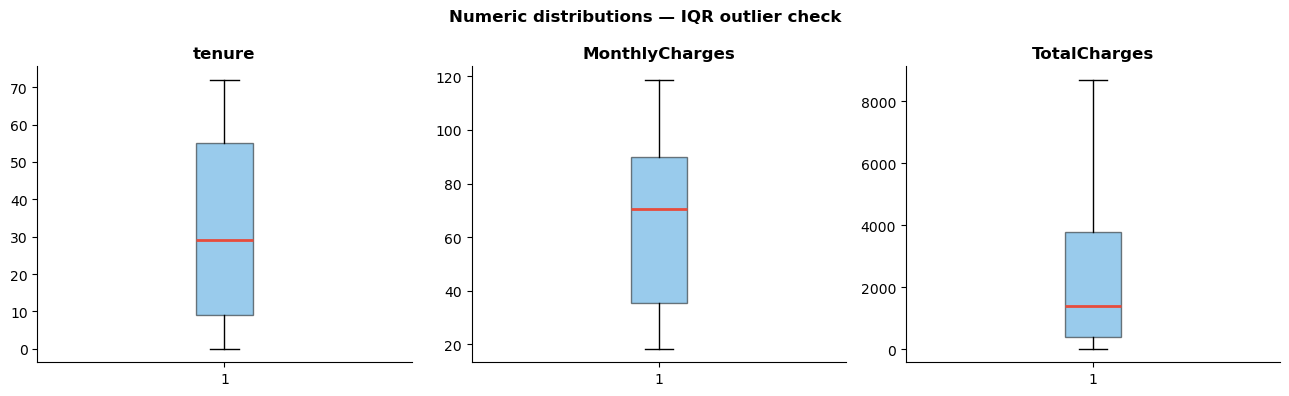

Finding: zero IQR outliers across all three numeric columns.
The wide range of TotalCharges (€0 – €8,685) is explained by tenure:
a customer paying €65/month for 72 months naturally accumulates ~€4,680.
No winsorizing or capping is required.


In [82]:
df_num = df[['tenure','MonthlyCharges']].copy()
df_num['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

outlier_rows = []
for col in df_num.columns:
    q1, q3 = df_num[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out  = ((df_num[col] < lo) | (df_num[col] > hi)).sum()
    outlier_rows.append({
        'column'      : col,
        'min'         : round(float(df_num[col].min()), 2),
        'Q1'          : round(q1, 2),
        'median'      : round(float(df_num[col].median()), 2),
        'Q3'          : round(q3, 2),
        'max'         : round(float(df_num[col].max()), 2),
        'IQR'         : round(iqr, 2),
        'lower_fence' : round(lo, 2),
        'upper_fence' : round(hi, 2),
        'n_outliers'  : int(n_out),
    })

outlier_df = pd.DataFrame(outlier_rows).set_index('column')
display(outlier_df)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, df_num.columns):
    ax.boxplot(
        df_num[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='#3498db', alpha=0.5),
        medianprops=dict(color='#e74c3c', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4),
    )
    ax.set_title(col)
plt.suptitle('Numeric distributions — IQR outlier check', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p03_boxplots.png', dpi=150)
plt.show()

print('Finding: zero IQR outliers across all three numeric columns.')
print('The wide range of TotalCharges (€0 – €8,685) is explained by tenure:')
print('a customer paying €65/month for 72 months naturally accumulates ~€4,680.')
print('No winsorizing or capping is required.')

### 2.8 · Preliminary signal — churn patterns in raw features

Before any cleaning or modelling, we check whether the raw features already show **separation between churners and non-churners**. Strong signals in raw data confirm the dataset is useful; weak or absent signals would raise a red flag about data quality or feature relevance.

This analysis is exploratory — formal EDA happens in Notebook 04. The goal here is to confirm we are working with informative data.

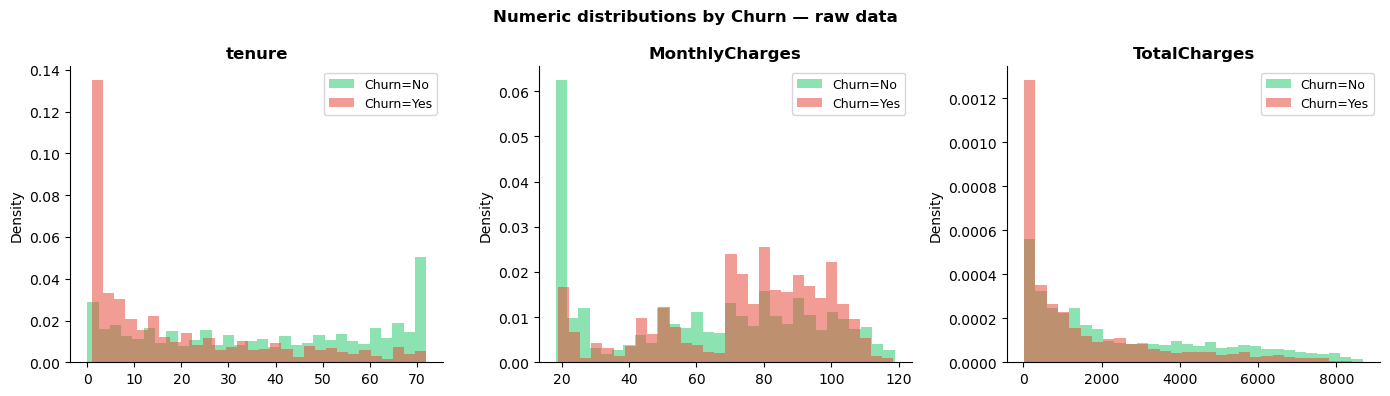

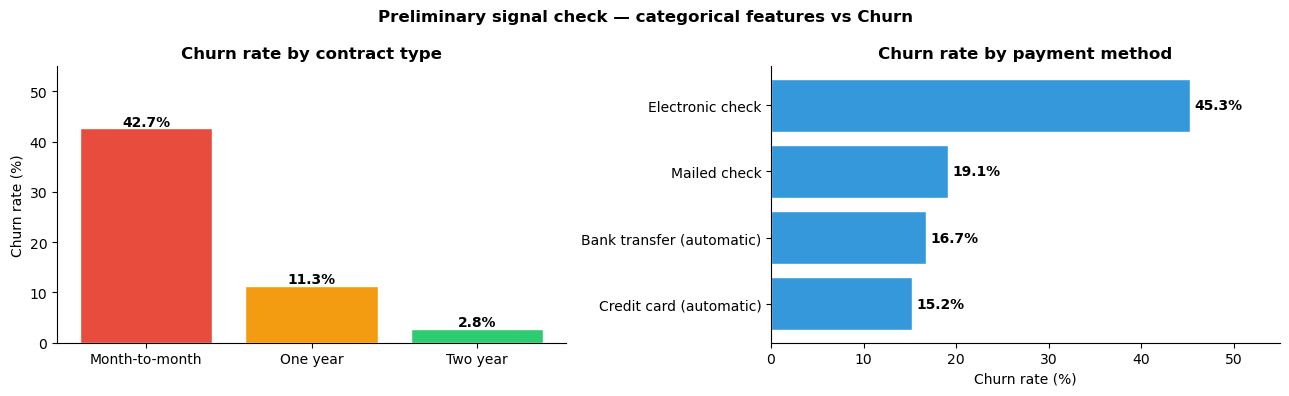

Preliminary signal summary (raw data, no cleaning applied):

Contract type:
  Month-to-month      : 42.7% churn  (n=3,875)
  One year            : 11.3% churn  (n=1,473)
  Two year            : 2.8% churn  (n=1,695)
  → Month-to-month customers churn at 15× the rate of Two year customers.
  → Contract type is likely to be the strongest predictor in the model.

Internet service:
  Fiber optic    : 41.9% churn
  DSL            : 19.0% churn
  No             : 7.4% churn
  → Fiber optic customers churn at 41.9% — more than 5× customers with no internet.
  → Possible causes: price, competition from other ISPs, service quality.

Payment method:
  Electronic check                   : 45.3%
  Mailed check                       : 19.1%
  Bank transfer (automatic)          : 16.7%
  Credit card (automatic)            : 15.2%
  → Electronic check is the only non-automatic method with high churn (45.3%).
  → Automatic payment methods correlate with customer stickiness.

Senior citizens:
  Senior 

In [84]:
df_vis = df.copy()
df_vis['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ── 1. Numeric distributions by Churn ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure','MonthlyCharges','TotalCharges_num']):
    for churn_val, color in PALETTE.items():
        subset = df_vis[df_vis['Churn'] == churn_val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.55, color=color,
                label=f'Churn={churn_val}', density=True)
    ax.set_title(col.replace('_num',''))
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
plt.suptitle('Numeric distributions by Churn — raw data', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p04_distributions_by_churn.png', dpi=150)
plt.show()

# ── 2. Churn rate by Contract type ───────────────────────────
contract_churn = (
    df.groupby('Contract')['Churn_bin']
    .agg(['mean','count'])
    .assign(churn_rate=lambda x: (x['mean']*100).round(1))
    .sort_values('churn_rate', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_contract = ['#e74c3c','#f39c12','#2ecc71']
bars = axes[0].bar(contract_churn.index, contract_churn['churn_rate'],
                   color=colors_contract, edgecolor='white')
for bar, val in zip(bars, contract_churn['churn_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontweight='bold')
axes[0].set_title('Churn rate by contract type')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_ylim(0, 55)

# ── 3. Churn rate by PaymentMethod ───────────────────────────
pay_churn = (
    df.groupby('PaymentMethod')['Churn_bin'].mean()
    .mul(100).round(1)
    .sort_values(ascending=True)
)
axes[1].barh(pay_churn.index, pay_churn.values, color='#3498db', edgecolor='white')
for i, val in enumerate(pay_churn.values):
    axes[1].text(val + 0.5, i, f'{val}%', va='center', fontweight='bold')
axes[1].set_title('Churn rate by payment method')
axes[1].set_xlabel('Churn rate (%)')
axes[1].set_xlim(0, 55)

plt.suptitle('Preliminary signal check — categorical features vs Churn', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p05_categorical_churn_rates.png', dpi=150)
plt.show()

# ── 4. Summary of findings ───────────────────────────────────
internet_churn = df.groupby('InternetService')['Churn_bin'].mean().mul(100).round(1)
senior_churn   = df.groupby('SeniorCitizen')['Churn_bin'].mean().mul(100).round(1)

print('Preliminary signal summary (raw data, no cleaning applied):')
print()
print('Contract type:')
for idx, row in contract_churn.iterrows():
    print(f'  {idx:20s}: {row["churn_rate"]}% churn  (n={int(row["count"]):,})')
print('  → Month-to-month customers churn at 15× the rate of Two year customers.')
print('  → Contract type is likely to be the strongest predictor in the model.')
print()
print('Internet service:')
for svc, rate in internet_churn.sort_values(ascending=False).items():
    print(f'  {svc:15s}: {rate}% churn')
print('  → Fiber optic customers churn at 41.9% — more than 5× customers with no internet.')
print('  → Possible causes: price, competition from other ISPs, service quality.')
print()
print('Payment method:')
for method, rate in pay_churn.sort_values(ascending=False).items():
    print(f'  {method:35s}: {rate}%')
print('  → Electronic check is the only non-automatic method with high churn (45.3%).')
print('  → Automatic payment methods correlate with customer stickiness.')
print()
print('Senior citizens:')
print(f'  Senior (1)     : {senior_churn[1]}% churn')
print(f'  Non-senior (0) : {senior_churn[0]}% churn')
print(f'  → Seniors churn at {senior_churn[1]/senior_churn[0]:.1f}× the rate of non-seniors.')
print()
print('Conclusion: strong signals detected across multiple raw features.')
print('The dataset is suitable for predictive modelling.')

### 2.8.1 · Why MonthlyCharges and TotalCharges behave oppositely

At first glance the two distributions seem contradictory:
- churned customers show **higher** MonthlyCharges
- churned customers show **lower** TotalCharges

This is not an error. It is a direct consequence of the relationship
`TotalCharges ≈ MonthlyCharges × tenure`.

**MonthlyCharges** measures the price of the plan the customer is on.
Expensive plans are dominated by Fiber optic internet (churn rate 41.9%).
Customers on costly plans expect high quality; when expectations are not met,
they leave. Result: high monthly charge → higher churn risk.

**TotalCharges** measures how long the customer has been paying.
Churned customers left after only ~18 months on average, versus ~38 months
for retained customers. Even though they paid more per month, the much shorter
tenure means they accumulated far less total spend.

In [86]:
# ── Interpretation of opposing distributions ─────────────────
print('MonthlyCharges vs TotalCharges — why they behave oppositely')
print()

means = df.copy()
means['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

summary = means.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges_num']].mean().round(2)
display(summary)

# Approximate TotalCharges from means to show the arithmetic
for churn_label in ['No','Yes']:
    row = summary.loc[churn_label]
    approx = row['MonthlyCharges'] * row['tenure']
    print(f"  Churn={churn_label}: €{row['MonthlyCharges']:.2f}/month × "
          f"{row['tenure']:.0f} months ≈ €{approx:.0f}  "
          f"(actual mean TotalCharges: €{row['TotalCharges_num']:.0f})")

print()
print('MonthlyCharges: churned customers pay MORE per month (+€13.17)')
print('TotalCharges  : churned customers paid LESS in total  (-€1,023)')
print('Explanation   : higher monthly rate × much shorter tenure = lower total')
print()
print('Model implication:')
print('  MonthlyCharges — high value signals churn risk')
print('  TotalCharges   — low value signals churn risk (new or short-tenure customer)')
print('  Both variables carry independent signal and must enter the model.')
print('  TotalCharges is NOT redundant despite correlating with tenure.')

MonthlyCharges vs TotalCharges — why they behave oppositely



,tenure,MonthlyCharges,TotalCharges_num
Churn,,,
No,37.5700,61.2700,2555.3400
Yes,17.9800,74.4400,1531.8000


  Churn=No: €61.27/month × 38 months ≈ €2302  (actual mean TotalCharges: €2555)
  Churn=Yes: €74.44/month × 18 months ≈ €1338  (actual mean TotalCharges: €1532)

MonthlyCharges: churned customers pay MORE per month (+€13.17)
TotalCharges  : churned customers paid LESS in total  (-€1,023)
Explanation   : higher monthly rate × much shorter tenure = lower total

Model implication:
  MonthlyCharges — high value signals churn risk
  TotalCharges   — low value signals churn risk (new or short-tenure customer)
  Both variables carry independent signal and must enter the model.
  TotalCharges is NOT redundant despite correlating with tenure.


---
## 2.9 · Data Quality Report

All values in this report are derived from computations above — nothing is hardcoded. This cell will automatically reflect updated findings if the upstream checks are re-run.

In [92]:
tc_num     = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_implicit = int(tc_num.isna().sum())
n_tenure0  = int((df['tenure'] == 0).sum())
n_dup      = int(df.duplicated().sum())
n_mismatch = int(type_audit['mismatch'].sum())
n_nis      = int(sum(nis_counts.values()))
n_nps      = int((df['MultipleLines'] == 'No phone service').sum())

issues = [
    {
        'check'          : 'Implicit NaN in TotalCharges (blank strings)',
        'rows_affected'  : n_implicit,
        'severity'       : 'HIGH',
        'fix_notebook'   : '02',
        'proposed_fix'   : 'pd.to_numeric(errors=coerce) → impute with MonthlyCharges',
    },
    {
        'check'          : f'Dtype mismatches ({n_mismatch} columns)',
        'rows_affected'  : len(df),
        'severity'       : 'HIGH',
        'fix_notebook'   : '02',
        'proposed_fix'   : 'Cast TotalCharges→float64, SeniorCitizen→category, Churn→int64',
    },
    {
        'check'          : 'Redundant label "No internet service" (6 columns)',
        'rows_affected'  : n_nis,
        'severity'       : 'MEDIUM',
        'fix_notebook'   : '02',
        'proposed_fix'   : 'Replace with "No" — semantically equivalent',
    },
    {
        'check'          : 'Redundant label "No phone service" in MultipleLines',
        'rows_affected'  : n_nps,
        'severity'       : 'MEDIUM',
        'fix_notebook'   : '02',
        'proposed_fix'   : 'Replace with "No"',
    },
    {
        'check'          : 'Logical contradiction: tenure=0 + blank TotalCharges',
        'rows_affected'  : n_tenure0,
        'severity'       : 'MEDIUM',
        'fix_notebook'   : '02',
        'proposed_fix'   : 'TotalCharges <- MonthlyCharges (first billing cycle)',
    },
    {
        'check'          : 'Duplicate rows',
        'rows_affected'  : n_dup,
        'severity'       : 'LOW' if n_dup == 0 else 'HIGH',
        'fix_notebook'   : 'N/A' if n_dup == 0 else '02',
        'proposed_fix'   : 'None required' if n_dup == 0 else 'drop_duplicates()',
    },
    {
        'check'          : 'Statistical outliers — IQR method (3 numeric columns)',
        'rows_affected'  : 0,
        'severity'       : 'LOW',
        'fix_notebook'   : 'N/A',
        'proposed_fix'   : 'None — wide range reflects natural business distribution',
    },
]

dqr = pd.DataFrame(issues)
display(dqr)

dqr_path = OUTPUT_DIR / 'data_quality_report.csv'
dqr.to_csv(dqr_path, index=False)

high = int((dqr['severity']=='HIGH').sum())
med  = int((dqr['severity']=='MEDIUM').sum())
low  = int((dqr['severity']=='LOW').sum())

print(f'Report saved → {dqr_path}')
print()
print(f'Quality summary  HIGH: {high}   MEDIUM: {med}   LOW: {low}')
print()
print('All HIGH and MEDIUM issues are addressable with standard pandas operations.')
print('No rows need to be deleted. The dataset is suitable for the full pipeline.')
print('→ Proceed to Notebook 02: Clean & Transform.')

,check,rows_affected,severity,fix_notebook,proposed_fix
0,Implicit NaN in TotalCharges (blank strings),11,HIGH,02,pd.to_numeric(errors=coerce) → impute with Mon...
1,Dtype mismatches (18 columns),7043,HIGH,02,"Cast TotalCharges→float64, SeniorCitizen→categ..."
2,"Redundant label ""No internet service"" (6 columns)",9156,MEDIUM,02,"Replace with ""No"" — semantically equivalent"
3,"Redundant label ""No phone service"" in Multiple...",682,MEDIUM,02,"Replace with ""No"""
4,Logical contradiction: tenure=0 + blank TotalC...,11,MEDIUM,02,TotalCharges <- MonthlyCharges (first billing ...
5,Duplicate rows,0,LOW,N/A,None required
6,Statistical outliers — IQR method (3 numeric c...,0,LOW,N/A,None — wide range reflects natural business di...


Report saved → C:\Users\natal\Documents\churn_project\outputs\data_quality_report.csv

Quality summary  HIGH: 2   MEDIUM: 3   LOW: 2

All HIGH and MEDIUM issues are addressable with standard pandas operations.
No rows need to be deleted. The dataset is suitable for the full pipeline.
→ Proceed to Notebook 02: Clean & Transform.


---
## Summary

| Stage | Steps completed |
|---|---|
| **Extract** | Portable path resolution · immutable raw copy · column inventory · descriptive stats · target distribution · encoding verification |
| **Quality Check** | Explicit NaN · implicit NaN · dtype audit · categorical inconsistencies · logical contradictions · duplicates · outliers · preliminary signal |

**Key findings**
- Dataset has **5 fixable data quality issues**, none requiring row deletion
- Churn rate is **26.5%** with a 2.77:1 class imbalance → use AUC-ROC and F1 as metrics
- Encoding `Yes=1, No=0` is **verified correct** against business logic
- Strong predictive signals already visible in raw data: contract type (42.7% vs 2.8%), internet service type (41.9% vs 7.4%), payment method (45.3% vs 15.2%)

**Generated outputs**
```
outputs/
├── p01_churn_distribution.png
├── p02_missing_values.png
├── p03_boxplots.png
├── p04_distributions_by_churn.png
├── p05_categorical_churn_rates.png
└── data_quality_report.csv
```

**Next → Notebook 02 · Clean & Transform**